In [2]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [3]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
model = TinyNet()
model.load_state_dict(torch.load('tinynet_baseline.pth'))
model.eval()
print("Baseline model loaded!")




Baseline model loaded!


In [5]:
import os
print(os.getcwd())

c:\Users\hafsa\Desktop\TinyML_code


In [6]:
import os
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

.\tinynet_baseline.pth


In [7]:
def check_sparsity(model):
    total = 0
    zeros = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            total+= param.nelement()
            zeros += float(torch.sum(param ==0))
    print(f"Global sparsity: {100 * zeros / total:.1f}%")
check_sparsity(model)

Global sparsity: 0.0%


# PRUNING

In [8]:
prune.l1_unstructured(model.conv1, name='weight', amount=0.4)
prune.l1_unstructured(model.conv2, name='weight', amount=0.4)
prune.l1_unstructured(model.fc1, name='weight', amount=0.4)
prune.l1_unstructured(model.fc2, name='weight', amount=0.4)

check_sparsity(model)



Global sparsity: 0.0%


# SAME SPARSITY BECAUSE OF MASKING

In [9]:
def check_sparsity(model):
    total = 0
    zeros = 0
    for name, module in model.named_modules():
        if isinstance(module,(nn.Conv2d,nn.Linear) ):
            weight = module.weight
            total+= weight.nelement()
            zeros += float(torch.sum(weight ==0))
    print(f"Global sparsity: {100 * zeros / total:.1f}%")
check_sparsity(model)

Global sparsity: 40.0%


Did pruning hurt the accuracy? By how much?

In [10]:
# Define test loader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_data = torchvision.datasets.MNIST('./data', train=False, 
                                        transform=transform, download=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Evaluate function
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.2f}%")

evaluate(model, test_loader)

Accuracy: 98.56%


Testing Sparsity levels

In [11]:
def load_fresh_model():
    model = TinyNet()
    model.load_state_dict(torch.load('tinynet_baseline.pth'))
    model.eval()
    return model

In [12]:
def prune_model(model,amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1, name='weight', amount=amount)
    prune.l1_unstructured(model.fc2, name='weight', amount=amount)
    return model

In [13]:
sparsity_level = [0.2,0.4,0.6,0.8]
for amount in sparsity_level:
    model = load_fresh_model()
    model = prune_model(model,amount)
    check_sparsity(model)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model,test_loader)
    print("__________")


Global sparsity: 20.0%
Sparsity: 20% | Accuracy: 98.60%
__________
Global sparsity: 40.0%
Sparsity: 40% | Accuracy: 98.56%
__________
Global sparsity: 60.0%
Sparsity: 60% | Accuracy: 96.99%
__________
Global sparsity: 80.0%
Sparsity: 80% | Accuracy: 56.83%
__________


Test at 65%, 70%, 75% sparsity to pinpoint exactly where accuracy collapses.

In [14]:
sparsity_levels = [0.65, 0.70, 0.75]

for amount in sparsity_levels:
    model = load_fresh_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, test_loader)
    print("---")

Sparsity: 65% | Accuracy: 95.01%
---
Sparsity: 70% | Accuracy: 86.77%
---
Sparsity: 75% | Accuracy: 83.12%
---


In [15]:
sparsity_levels = [0.66, 0.67, 0.68,0.69]

for amount in sparsity_levels:
    model = load_fresh_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, test_loader)
    print("---")

Sparsity: 66% | Accuracy: 94.05%
---
Sparsity: 67% | Accuracy: 91.34%
---
Sparsity: 68% | Accuracy: 90.96%
---
Sparsity: 69% | Accuracy: 87.75%
---


In [16]:
sparsity_levels = [0.76, 0.77, 0.78,0.79]

for amount in sparsity_levels:
    model = load_fresh_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, test_loader)
    print("---")

Sparsity: 76% | Accuracy: 77.21%
---
Sparsity: 77% | Accuracy: 81.90%
---
Sparsity: 78% | Accuracy: 80.44%
---
Sparsity: 79% | Accuracy: 63.22%
---


LAYER SENSITIVITY ANALYSIS

In [17]:
layers = {
    'conv1': model.conv1,
    'conv2' : model.conv2,
    'fc1' : model.fc1,
    'fc2': model.fc2
}

for layer_name,layer in layers.items():
    fresh = load_fresh_model()

    prune.l1_unstructured(
        getattr(fresh,layer_name),
        name = 'weight',
        amount=0.7
    )

    print(f"Pruned {layer_name} at 70%", end=" | ")
    evaluate(fresh, test_loader) 

Pruned conv1 at 70% | Accuracy: 98.46%
Pruned conv2 at 70% | Accuracy: 97.98%
Pruned fc1 at 70% | Accuracy: 98.68%
Pruned fc2 at 70% | Accuracy: 97.03%


In [18]:

def smart_prune_model(model):
    prune.l1_unstructured(model.fc1, name='weight', amount=0.80)   # most robust
    prune.l1_unstructured(model.conv1, name='weight', amount=0.70) # third
    prune.l1_unstructured(model.conv2, name='weight', amount=0.65) # second
    prune.l1_unstructured(model.fc2, name='weight', amount=0.50)   # most sensitive
    return model


fresh = load_fresh_model()
fresh = smart_prune_model(fresh)
check_sparsity(fresh)
evaluate(fresh, test_loader)

Global sparsity: 79.3%
Accuracy: 92.39%


Same sparsity level — but 29% better accuracy!

In [1]:
!pip3 install matplotlib

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.4 MB 1.2 MB/s eta 0:00:02
   ---------------------- ----------------- 1.3/2.4 MB 1.6 MB/s eta 0:00:01
   ------------------------------- -------- 1.8/2.4 MB 1.8 MB/s eta 0:00:01
   ------------------------------- -------- 1.8/2.4 MB 1.8 MB/s eta 0:00:01
   -------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\hafsa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


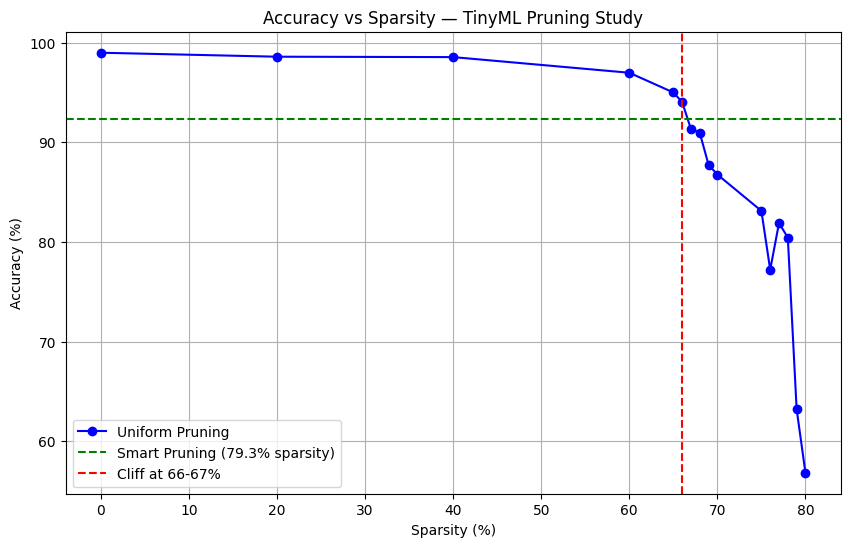

Graph saved!


In [2]:
import matplotlib.pyplot as plt

sparsity = [0, 20, 40, 60, 65, 66, 67, 68, 69, 70, 75, 76, 77, 78, 79, 80]
accuracy = [99, 98.60, 98.56, 96.99, 95.01, 94.05, 91.34, 90.96, 87.75, 86.77, 83.12, 77.21, 81.90, 80.44, 63.22, 56.83]

plt.figure(figsize=(10, 6))
plt.plot(sparsity, accuracy, 'b-o', label='Uniform Pruning')
plt.axhline(y=92.39, color='g', linestyle='--', label='Smart Pruning (79.3% sparsity)')
plt.axvline(x=66, color='r', linestyle='--', label='Cliff at 66-67%')
plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Sparsity — TinyML Pruning Study')
plt.legend()
plt.grid(True)
plt.savefig('pruning_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved!")